# Chest X-Ray Classification - VGG19 + Fine-Tuning

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
import os, glob
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

2026-09-05 19:29:00.469920: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
DATA_DIR = "/Users/admin/Desktop/all/GITHUB_allProjects/DL/Data"
WEIGHTS_PATH = "/Users/admin/Desktop/all/GITHUB_allProjects/DL/Data/vgg19_weights_tf_dim_ordering_tf_kernels_notop.h5"
# https://github.com/fchollet/deep-learning-models/releases/download/v0.1/vgg19_weights_tf_dim_ordering_tf_kernels_notop.h5
IMG_SIZE = 224
BATCH_SIZE = 8
SEED = 42

# Load Data

In [15]:
def list_files_labels(root):
    classes = sorted([c for c in os.listdir(root) if os.path.isdir(os.path.join(root, c))])
    paths, labels = [], []
    for idx, c in enumerate(classes):
        for f in glob.glob(os.path.join(root, c, "*")):
            paths.append(f)
            labels.append(idx)
    return np.array(paths), np.array(labels), classes


train_paths, train_labels, class_names = list_files_labels(f"{DATA_DIR}/train")
test_paths, test_labels, _ = list_files_labels(f"{DATA_DIR}/test")
num_classes = len(class_names)

print(f"Found {len(train_paths)} files belonging to {num_classes} classes.")

tr_paths, val_paths, tr_labels, val_labels = train_test_split(
    train_paths,
    train_labels,
    test_size=0.15,
    stratify=train_labels,
    random_state=SEED,
)

print(f"Using {len(tr_paths)} files for training.")
print(f"Found {len(train_paths)} files belonging to {num_classes} classes.")
print(f"Using {len(val_paths)} files for validation.")
print(f"Found {len(test_paths)} files belonging to {num_classes} classes.")
print(f"Classes ({num_classes}): {class_names}")

print("train per class:", np.bincount(tr_labels))
print("val per class:", np.bincount(val_labels))

Found 250 files belonging to 5 classes.
Using 212 files for training.
Found 250 files belonging to 5 classes.
Using 38 files for validation.
Found 150 files belonging to 5 classes.
Classes (5): ['Bacterial', 'Covid', 'Enlarged Cardiomediastinum', 'Normal', 'Viral']
train per class: [42 43 42 42 43]
val per class: [8 7 8 8 7]


In [16]:
def decode_img(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    label = tf.one_hot(label, num_classes)
    return img, label

def make_ds(paths, labels, shuffle=False, augment=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(len(paths), seed=SEED)
    ds = ds.map(decode_img, num_parallel_calls=tf.data.AUTOTUNE)
    if augment:
        ds = ds.map(lambda x, y: (augmentation(x, training=True), y), num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# Augmentation

In [17]:
augmentation = keras.Sequential([
    keras.layers.RandomFlip("horizontal"),
    keras.layers.RandomRotation(0.05),
    keras.layers.RandomZoom(0.15),
    keras.layers.RandomContrast(0.1),
])

train_ds = make_ds(tr_paths, tr_labels, shuffle=True, augment=True)
val_ds = make_ds(val_paths, val_labels)
test_ds = make_ds(test_paths, test_labels)

2026-09-05 23:02:34.891680: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


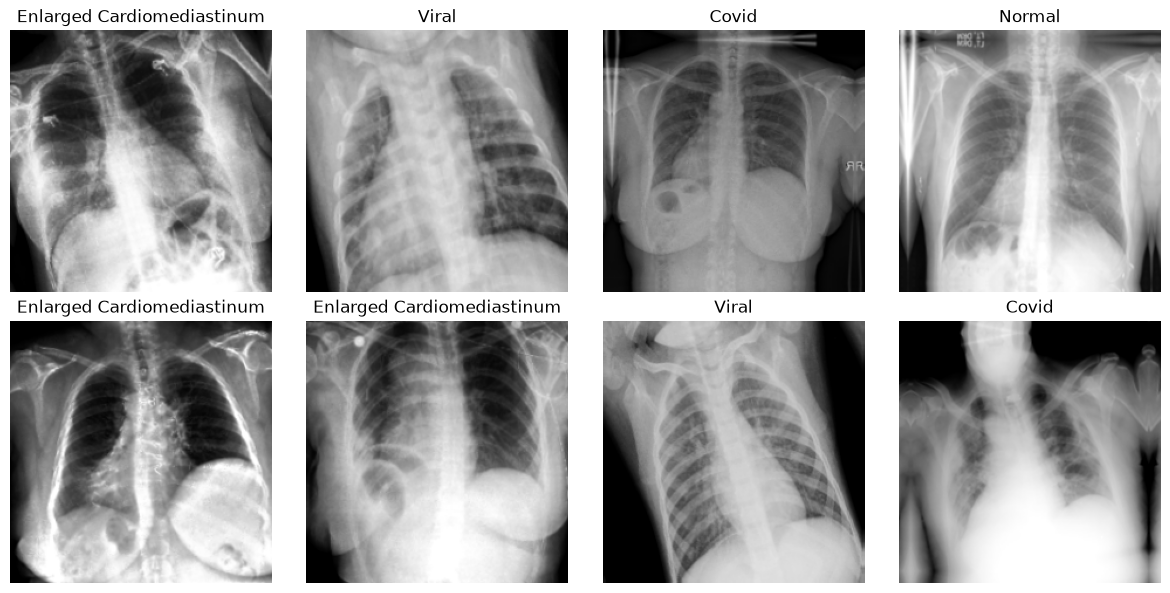

In [18]:
plt.figure(figsize=(12, 6))
for images, labels in train_ds.take(1):
    for i in range(min(8, images.shape[0])):
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[np.argmax(labels[i])])
        plt.axis("off")
plt.tight_layout()
plt.show()

# Define Model

In [6]:
base_model = keras.applications.VGG19(include_top=False, weights=WEIGHTS_PATH,
                                       input_shape=(IMG_SIZE, IMG_SIZE, 3))
base_model.trainable = False

inputs = keras.layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = keras.applications.vgg19.preprocess_input(inputs)
x = base_model(x, training=False)
x = keras.layers.GlobalAveragePooling2D()(x)
x = keras.layers.BatchNormalization()(x)
x = keras.layers.Dropout(0.3)(x)
x = keras.layers.Dense(256, activation="relu", kernel_regularizer=keras.regularizers.l2(1e-4))(x)
x = keras.layers.Dropout(0.3)(x)
outputs = keras.layers.Dense(num_classes, activation="softmax")(x)

model = keras.models.Model(inputs, outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_2[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ vgg19 (Functional)  │ (None, 7, 7, 512) │ 20,024,384 │ add[0][0]         │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 512)       │          0 │ vgg19[0][0]       │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 512)       │      2,048 │ global_average_p… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 512)       │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 256)       │    131,328 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 5)         │      1,285 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 20,159,045 (76.90 MB)

 Trainable params: 133,637 (522.02 KB)

 Non-trainable params: 20,025,408 (76.39 MB)

# Compile & Fit (frozen backbone)

In [7]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-4),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

checkpoint_cb = keras.callbacks.ModelCheckpoint(f"{DATA_DIR}/outputs/best_model.keras",
                                                 save_best_only=True, monitor="val_accuracy")
earlystop_cb = keras.callbacks.EarlyStopping(monitor="val_loss", patience=8, restore_best_weights=True)
reduce_lr_cb = keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4)

# was still improving at epoch 30 last run - giving it more room before fine-tuning
history = model.fit(train_ds, validation_data=val_ds, epochs=50,
                     callbacks=[checkpoint_cb, earlystop_cb, reduce_lr_cb])

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 47s 2s/step - accuracy: 0.1887 - loss: 2.3533 - val_accuracy: 0.2105 - val_loss: 2.4829 - learning_rate: 1.0000e-04
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 54s 2s/step - accuracy: 0.3066 - loss: 1.8507 - val_accuracy: 0.3421 - val_loss: 1.7886 - learning_rate: 1.0000e-04
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.3538 - loss: 1.6299 - val_accuracy: 0.5000 - val_loss: 1.4108 - learning_rate: 1.0000e-04
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.4623 - loss: 1.4249 - val_accuracy: 0.6053 - val_loss: 1.1685 - learning_rate: 1.0000e-04
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.5236 - loss: 1.2358 - val_accuracy: 0.6053 - val_loss: 1.0155 - learning_rate: 1.0000e-04
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.4764 - loss: 1.3279 - val_accuracy: 0.6579 - val_loss: 0.9132 - learning_rate: 1.0000e-04
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.6085 - loss:

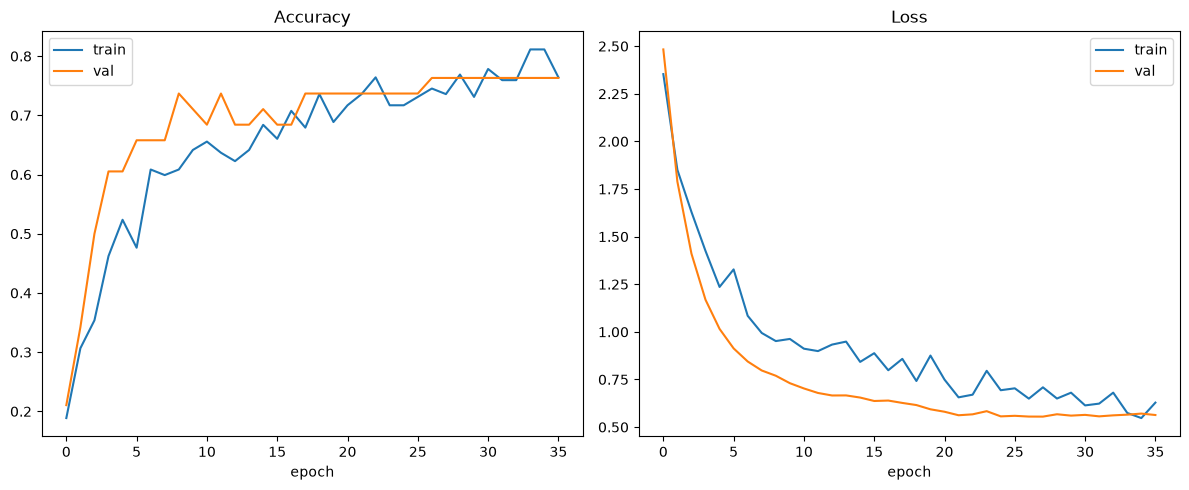

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(history.history["accuracy"], label="train")
axes[0].plot(history.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history.history["loss"], label="train")
axes[1].plot(history.history["val_loss"], label="val")
axes[1].set_title("Loss")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()


# Fine-Tune (unfreeze only the last conv layer)

In [ ]:
# unfreezing just block5_conv4, and tightening dropout for this phase
base_model.trainable = True
for layer in base_model.layers:
    if layer.name != "block5_conv4":
        layer.trainable = False

for layer in model.layers:
    if isinstance(layer, keras.layers.Dropout):
        layer.rate = 0.5

model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5),
              loss="categorical_crossentropy",
              metrics=["accuracy"])

earlystop_ft_cb = keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True)

history_ft = model.fit(train_ds, validation_data=val_ds, epochs=30,
                        callbacks=[checkpoint_cb, earlystop_ft_cb, reduce_lr_cb])

Epoch 1/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 56s 2s/step - accuracy: 0.6274 - loss: 1.1268 - val_accuracy: 0.7632 - val_loss: 0.5451 - learning_rate: 1.0000e-05
Epoch 2/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 48s 2s/step - accuracy: 0.6557 - loss: 1.0981 - val_accuracy: 0.7632 - val_loss: 0.5262 - learning_rate: 1.0000e-05
Epoch 3/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.7075 - loss: 0.7745 - val_accuracy: 0.7632 - val_loss: 0.5192 - learning_rate: 1.0000e-05
Epoch 4/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.6368 - loss: 1.0827 - val_accuracy: 0.7895 - val_loss: 0.5181 - learning_rate: 1.0000e-05
Epoch 5/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.6557 - loss: 0.9643 - val_accuracy: 0.7895 - val_loss: 0.5179 - learning_rate: 1.0000e-05
Epoch 6/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 49s 2s/step - accuracy: 0.6462 - loss: 1.0087 - val_accuracy: 0.8158 - val_loss: 0.5208 - learning_rate: 1.0000e-05
Epoch 7/30
27/27 ━━━━━━━━━━━━━━━━━━━━ 45s 2s/step - accuracy: 0.6792 - loss:

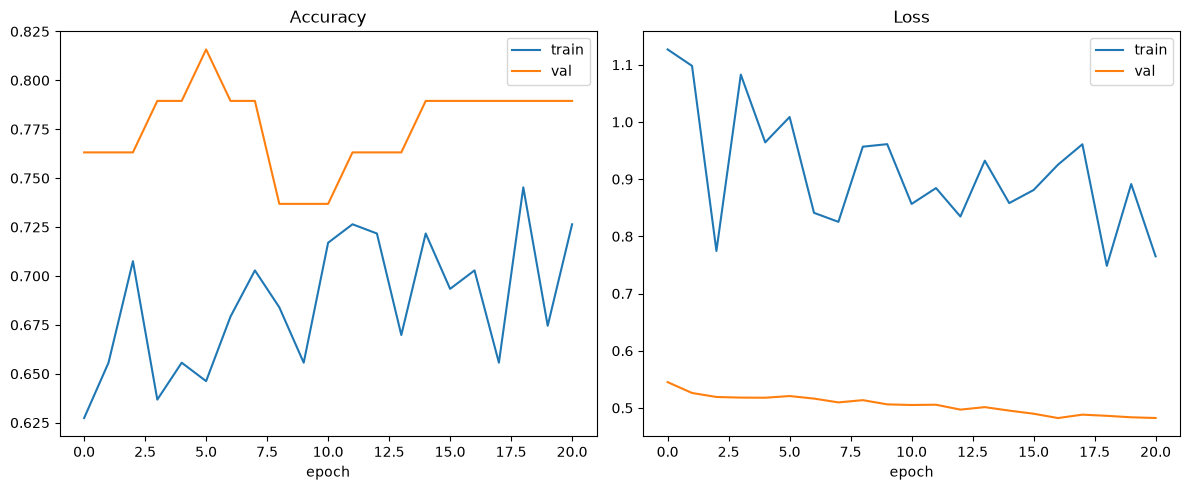

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(history_ft.history["accuracy"], label="train")
axes[0].plot(history_ft.history["val_accuracy"], label="val")
axes[0].set_title("Accuracy")
axes[0].set_xlabel("epoch")
axes[0].legend()

axes[1].plot(history_ft.history["loss"], label="train")
axes[1].plot(history_ft.history["val_loss"], label="val")
axes[1].set_title("Loss")
axes[1].set_xlabel("epoch")
axes[1].legend()

plt.tight_layout()


# Evaluate

In [12]:
model.evaluate(test_ds)

19/19 ━━━━━━━━━━━━━━━━━━━━ 26s 1s/step - accuracy: 0.7867 - loss: 0.6173


[0.6173244118690491, 0.7866666913032532]

                            precision    recall  f1-score   support

                 Bacterial       0.69      0.83      0.76        30
                     Covid       0.77      0.77      0.77        30
Enlarged Cardiomediastinum       0.93      0.93      0.93        30
                    Normal       0.85      0.77      0.81        30
                     Viral       0.70      0.63      0.67        30

                  accuracy                           0.79       150
                 macro avg       0.79      0.79      0.79       150
              weighted avg       0.79      0.79      0.79       150



2026-09-05 22:58:54.332966: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


Text(50.385633680555536, 0.5, 'True')

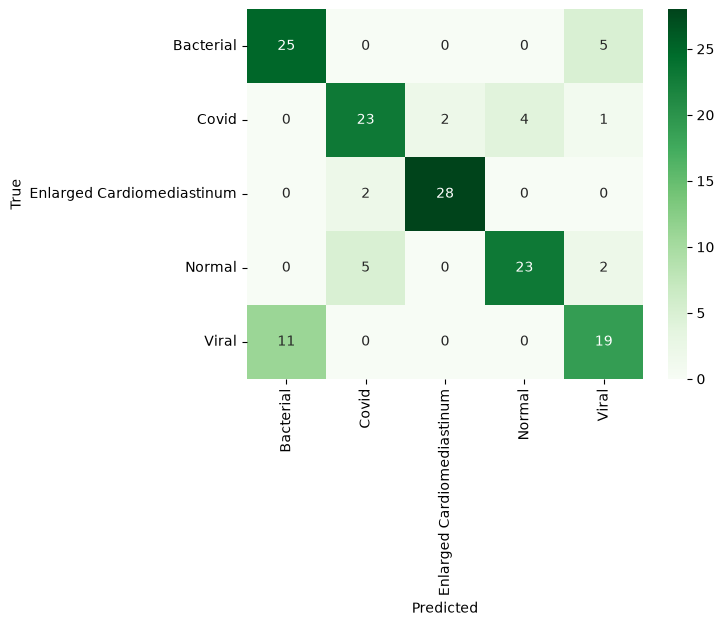

In [13]:
y_true, y_pred = [], []
for x, y in test_ds:
    preds = model.predict(x, verbose=0)
    y_true.extend(np.argmax(y.numpy(), axis=1))
    y_pred.extend(np.argmax(preds, axis=1))

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt="d", xticklabels=class_names, yticklabels=class_names, cmap="Greens")
plt.xlabel("Predicted"); plt.ylabel("True")

## Random test predictions (visual check)

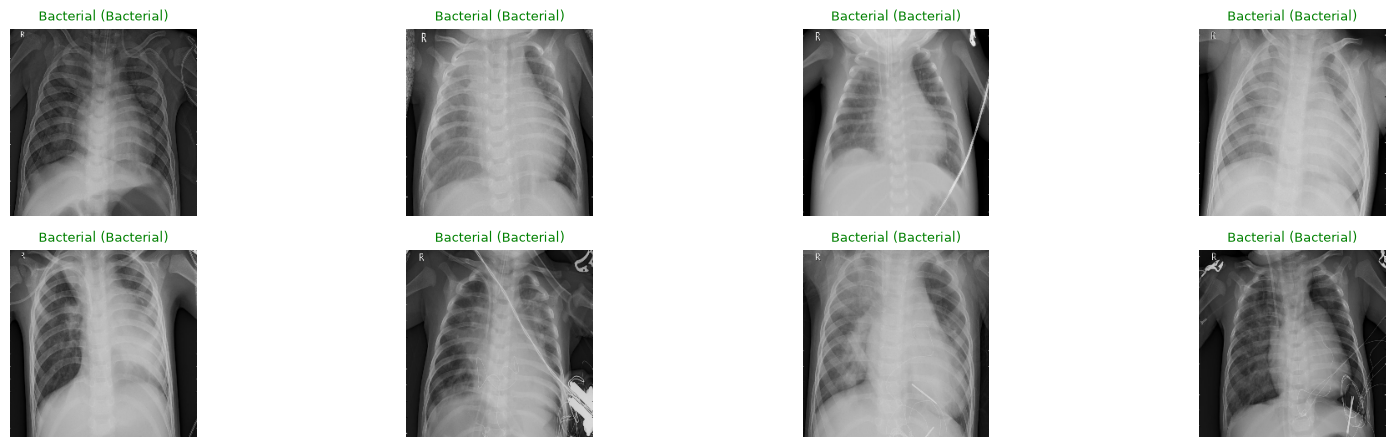

2026-09-05 23:02:00.884146: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [14]:
for images, labels in test_ds.take(1):
    preds = model.predict(images, verbose=0)
    plt.figure(figsize=(16, 9))
    n = min(16, images.shape[0])
    for i in range(n):
        ax = plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        pred_idx = np.argmax(preds[i])
        true_idx = np.argmax(labels[i].numpy())
        color = "green" if pred_idx == true_idx else "red"
        plt.title(f"{class_names[pred_idx]} ({class_names[true_idx]})", color=color, fontsize=9)
        plt.axis("off")
    plt.tight_layout()
    plt.show()